# S&P 500 Options: Model Analysis

This notebook describes the complete official validation prediction populations produced by the
model execution notebooks. Model identity always includes family, configuration, and checkpoint.
Every comparison requires identical expected prediction keys and the same cross-validation
identity. Information coefficient and related diagnostics do not select a model or checkpoint.

Causal DML is reported separately because it estimates a treatment effect rather than a
cross-sectional prediction configuration.

In [1]:
"""Analyze complete S&P 500 options model populations."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import CausalResult, PredictionResult, Result
from case_studies.sp500_options.research_workflow import (
    official_prediction_catalog,
    open_study,
)

MODEL_POPULATIONS = (
    "sp500-options-linear-validation-v1",
    "sp500-options-gbm-validation-v1",
    "sp500-options-tabular-dl-validation-v1",
    "sp500-options-sequence-validation-v1",
)

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

## Complete population and its eligibility groups

Named immutable populations replace hash lists and registry-presence filters. The coverage table
comes from each prediction result's registered eligibility contract.

The four populations share one CV identity but not one eligibility set. A sequence model scores a
symbol only after its lookback window is available, so it is eligible on fewer symbols and fewer
rows than the cross-sectional families reading the same panel. The audit below reports one row per
eligibility group rather than asserting a single one, and the diagnostics that follow are read
within a group.

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
catalog = official_prediction_catalog(study, MODEL_POPULATIONS)

coverage_rows = []
for prediction_hash in catalog.get_column("prediction_hash"):
    result = Result.open(study, prediction_hash)
    if not isinstance(result, PredictionResult):
        raise TypeError(f"{prediction_hash} is not a prediction result")
    coverage = result.coverage()
    if coverage is None or coverage["status"] != "complete":
        raise RuntimeError(f"prediction {prediction_hash} has incomplete coverage")
    coverage_rows.append(
        {
            "prediction_hash": prediction_hash,
            "expected_key_digest": coverage["expected_key_digest"],
            "n_expected": coverage["n_expected"],
            "n_actual": coverage["n_actual"],
            "n_folds": coverage["n_folds_actual"],
        }
    )
coverage = pl.DataFrame(coverage_rows)

cv_identities = catalog.get_column("cv_identity").drop_nulls()
if cv_identities.is_empty() or cv_identities.n_unique() != 1:
    raise RuntimeError("official model populations do not share one CV identity")

Eligibility is grouped, not assumed identical. A sequence model needs a lookback window before it
can score a symbol, so it is eligible on strictly fewer rows than a cross-sectional model reading
the same panel - which is a property of the model class, not a defect. Requiring one eligibility
digest across all four populations would fail here for a correct run. What must hold is that every
prediction sharing an eligibility contract agrees on its dimensions exactly.

In [4]:
coverage = coverage.join(
    catalog.select("prediction_hash", "family"), on="prediction_hash", how="left"
)
for digest, group in coverage.group_by("expected_key_digest"):
    if group.select("n_expected", "n_actual", "n_folds").n_unique() != 1:
        raise RuntimeError(
            f"predictions sharing eligibility {digest[0]} disagree on coverage dimensions"
        )
    if group.filter(pl.col("n_actual") != pl.col("n_expected")).height:
        raise RuntimeError(f"eligibility {digest[0]} has predictions short of their declaration")

population_audit = (
    coverage.group_by("expected_key_digest")
    .agg(
        pl.col("family").unique().sort().str.join(", ").alias("families"),
        pl.len().alias("predictions"),
        pl.col("n_expected").first().alias("rows_per_prediction"),
        pl.col("n_folds").first().alias("folds"),
    )
    .with_columns(pl.lit(cv_identities[0]).alias("cv_identity"))
    .sort("rows_per_prediction", descending=True)
)
if population_audit.get_column("predictions").sum() != catalog.height:
    raise RuntimeError("the eligibility audit does not account for every declared prediction")
population_audit

expected_key_digest,families,predictions,rows_per_prediction,folds,cv_identity
str,str,u32,i64,i64,str
"""8c693b2eea6a52c0""","""gbm, linear, tabular_dl""",202,132210,2,"""a0eb91e068b045c5"""
"""edfcc6f3f06c78f5""","""deep_learning""",60,42186,2,"""a0eb91e068b045c5"""


## Predictive diagnostics

The table retains each checkpoint as a separate row. It supports descriptive comparison only;
strategy selection occurs after every row has an equal-weight validation backtest.

Each IC is computed on its own prediction's eligible rows, so two rows are directly comparable
only when the same eligibility group above covers both. A sequence checkpoint and a linear
checkpoint are scored on different populations, and the difference between their IC values
therefore mixes model behaviour with the population each was scored on.

In [5]:
analysis = (
    catalog.with_columns(
        pl.when(pl.col("checkpoint_value").is_null())
        .then(pl.col("checkpoint_kind").fill_null("final"))
        .otherwise(
            pl.concat_str(
                pl.col("checkpoint_kind"),
                pl.col("checkpoint_value").cast(pl.String),
                separator="=",
            )
        )
        .alias("checkpoint"),
    )
    .with_columns(
        pl.concat_str(
            "family",
            "config_name",
            "checkpoint",
            separator=" / ",
        ).alias("model_identity")
    )
    .select(
        "family",
        "config_name",
        "checkpoint",
        "model_identity",
        "ic_mean",
        "ic_std",
        "ic_t",
        "pct_positive",
        "prediction_hash",
    )
    .sort("family", "config_name", "checkpoint")
)
if analysis.select("ic_mean", "ic_std", "ic_t", "pct_positive").null_count().sum_horizontal().sum():
    raise RuntimeError("official model population has missing regression diagnostics")
analysis

family,config_name,checkpoint,model_identity,ic_mean,ic_std,ic_t,pct_positive,prediction_hash
str,str,str,str,f64,f64,f64,f64,str
"""deep_learning""","""lstm_h64""","""epoch=10""","""deep_learning / lstm_h64 / epo…",0.024725,0.022266,1.570362,1.0,"""1706327c649d"""
"""deep_learning""","""lstm_h64""","""epoch=100""","""deep_learning / lstm_h64 / epo…",-0.000603,0.021678,-0.03931,0.5,"""b5dcf7e86c73"""
"""deep_learning""","""lstm_h64""","""epoch=15""","""deep_learning / lstm_h64 / epo…",0.02223,0.021182,1.484188,1.0,"""26046cbbe5e7"""
"""deep_learning""","""lstm_h64""","""epoch=20""","""deep_learning / lstm_h64 / epo…",0.018555,0.021376,1.227538,0.5,"""399684346173"""
"""deep_learning""","""lstm_h64""","""epoch=25""","""deep_learning / lstm_h64 / epo…",0.021027,0.030317,0.980856,0.5,"""d6433f19ff36"""
…,…,…,…,…,…,…,…,…
"""tabular_dl""","""tabm_s""","""epoch=175""","""tabular_dl / tabm_s / epoch=17…",-0.0035,0.013342,-0.370997,0.5,"""0d8f243c0fc0"""
"""tabular_dl""","""tabm_s""","""epoch=200""","""tabular_dl / tabm_s / epoch=20…",-0.003422,0.012979,-0.372831,0.5,"""c29835f2c67c"""
"""tabular_dl""","""tabm_s""","""epoch=25""","""tabular_dl / tabm_s / epoch=25""",-0.001667,0.016621,-0.141831,0.5,"""3dacd9a621e8"""


In [6]:
family_summary = (
    analysis.group_by("family")
    .agg(
        pl.len().alias("configuration_checkpoints"),
        pl.col("ic_mean").min().alias("ic_min"),
        pl.col("ic_mean").median().alias("ic_median"),
        pl.col("ic_mean").max().alias("ic_max"),
    )
    .sort("family")
)
family_summary

family,configuration_checkpoints,ic_min,ic_median,ic_max
str,u32,f64,f64,f64
"""deep_learning""",60,-0.014256,0.001753,0.024725
"""gbm""",150,-0.014141,0.001541,0.012582
"""linear""",28,-0.011768,-0.010035,-0.002259
"""tabular_dl""",24,-0.004145,0.011881,0.017384


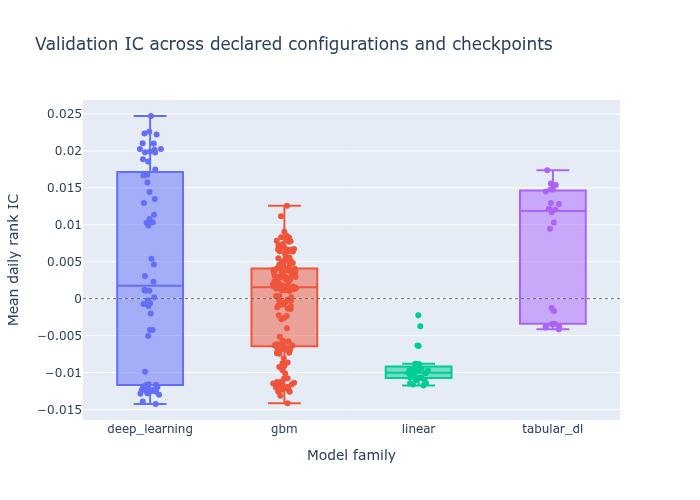

In [7]:
fig = go.Figure()
for family in analysis.get_column("family").unique(maintain_order=True):
    rows = analysis.filter(pl.col("family") == family)
    fig.add_trace(
        go.Box(
            name=family,
            y=rows.get_column("ic_mean").to_list(),
            text=rows.get_column("model_identity").to_list(),
            boxpoints="all",
            jitter=0.35,
            pointpos=0,
            hovertemplate="%{text}<br>validation IC %{y:+.4f}<extra></extra>",
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dot", line_color="#666666")
fig.update_layout(
    title="Validation IC across declared configurations and checkpoints",
    xaxis_title="Model family",
    yaxis_title="Mean daily rank IC",
    showlegend=False,
)
fig.show()

## Causal DML artifact

The causal result is not mixed into the predictive population or its checkpoint summaries.

It is resolved as canonical whatever tier this notebook runs at, because the populations above
are canonical whatever tier this notebook runs at. Asking a preview run for a preview causal
artifact would make the notebook fail unless `10_causal_dml` happened to have run in the same
workspace first, and would pair a preview estimate with canonical predictions if it had.

In [8]:
causal = CausalResult.one(study, label="ret_to_expiry", execution_tier="canonical")
if not causal.complete:
    raise RuntimeError("the causal DML artifact is incomplete")
causal_summary = pl.DataFrame(
    {
        "causal_hash": [causal.hash],
        "treatment": [causal.spec["computation"]["estimand"]["treatment"]],
        "outcome": [causal.spec["computation"]["estimand"]["outcome"]],
        "observations": [causal.metrics["n_obs"]],
        "effect": [causal.metrics["dml_effect"]],
        "hac_standard_error": [causal.metrics["dml_se_hac"]],
        "hac_p_value": [causal.metrics["p_value_hac"]],
        "placebo_p_value": [causal.metrics["refutation_p"]],
    }
)
causal_summary

causal_hash,treatment,outcome,observations,effect,hac_standard_error,hac_p_value,placebo_p_value
str,str,str,i64,f64,f64,f64,f64
"""0d451baa95b3""","""vrp_21d""","""ret_to_expiry""",166527,0.380758,0.319135,0.233209,0.009901


Predictive diagnostics and the causal estimate are now available for reader inspection. Neither
table changes the complete prediction population or selects a strategy.